# EHM Fleet Analytics — Phase 4: Remaining Useful Life (RUL) Prediction
### Beginner-friendly version with full explanations
**Author:** Shami | **Platform:** Google Colab

---

## What this notebook does

Phases 2 and 3 told us **what** the fleet looks like and **when** anomalies occur.

Phase 4 asks the hardest question yet: **how many cycles does each engine have left?**

This is called **Remaining Useful Life (RUL) prediction** — and it is the core capability of a modern Prognostics and Health Management (PHM) system.

We will build two models and compare them across five analytical questions:

| Model | Type | Why include it |
|---|---|---|
| **XGBoost** | Gradient-boosted trees | Strong on tabular data, fast to train, interpretable via SHAP |
| **LSTM** | Recurrent neural network | Designed for time-series, can remember patterns across many cycles |

---

## Five analytical questions

| # | Question | Why it matters |
|---|---|---|
| **Q1** | How accurately do XGBoost and LSTM predict RUL — and where does accuracy break down? | Accuracy is the foundation. But *where* it breaks down reveals more than the headline score. |
| **Q2** | In the 200 cycles after degradation starts, does LSTM track RUL more accurately than XGBoost? | This is where sequential memory should matter most. |
| **Q3** | Across the fleet, which features drive RUL predictions? Do they match the physics? | SHAP fleet-level — connects model behaviour to domain knowledge. |
| **Q4** | For each engine, which features dominate? Can we rank engines by fault signature? | SHAP per-engine — a diagnostic triage tool for maintenance controllers. |
| **Q5** | Do engines that start with lower EGT margin degrade faster than healthier-starting engines? | An original question: does starting condition predict degradation trajectory? |

---

## Three design decisions applied in this notebook

These were confirmed before Phase 4 began (see Handover v2.0, Section 7):

**Decision 1 — Piecewise RUL cap with engine-specific IDP**  
Before an engine's CUSUM alarm fires, RUL is capped at the value at that alarm cycle.  
After the alarm, RUL counts down normally.  
This follows Saxena (2008) but improves it: the cap is physically motivated and engine-specific.

**Decision 2 — post_IDP binary feature**  
A column set to 0 before the CUSUM alarm and 1 after.  
This tells the model explicitly that degradation has started — it does not have to infer it from noisy sensors.

**Decision 3 — Baseline normalisation per engine**  
Raw sensor features are normalised against each engine's own first-200-cycle baseline.  
Formula: `normalised = (value - baseline_mean) / baseline_std`  
This removes engine-to-engine manufacturing variation, so the model sees degradation drift, not absolute levels.

---

## How to run this notebook

1. Click on a cell
2. Press **Shift + Enter** to run it
3. Wait for the green tick
4. Move to the next cell

Run **top to bottom only**. Do not skip cells.

---

## Section 0 — Install and load libraries

We need a few extra libraries beyond Phase 3:

- **xgboost** — the gradient boosting model
- **shap** — calculates SHAP feature importance values
- **tensorflow / keras** — builds and trains the LSTM neural network
- **sklearn** — train/test splits, scaling, and error metrics

In [ ]:
# Install the libraries that are not pre-installed in Colab
# xgboost and shap need to be installed; tensorflow is pre-installed in Colab
!pip install xgboost shap --quiet

print('Installation complete.')

Installation complete.


In [ ]:
# --- Load all libraries ---

import pandas as pd                          # for data tables
import numpy as np                           # for maths and arrays
import matplotlib.pyplot as plt              # for charts
import matplotlib.gridspec as gridspec       # for multi-panel chart layouts
import seaborn as sns                        # for heatmaps
import warnings
warnings.filterwarnings('ignore')

# XGBoost — gradient boosted tree model
import xgboost as xgb

# SHAP — for explaining model predictions
import shap

# Scikit-learn tools
from sklearn.metrics import mean_squared_error, mean_absolute_error  # error metrics

# TensorFlow/Keras — for building the LSTM neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential     # a model built layer by layer
from tensorflow.keras.layers import LSTM, Dense, Dropout   # the layer types we use
from tensorflow.keras.callbacks import EarlyStopping       # stops training when it stops improving

# Colour scheme — same as Phases 2 and 3 for visual consistency
RED    = '#ef5350'
AMBER  = '#ffa726'
GREEN  = '#66bb6a'
BLUE   = '#42a5f5'
PURPLE = '#ab47bc'
TEAL   = '#26c6da'

# Chart styling — dark background, same as previous phases
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor']   = '#1a1d2e'
plt.rcParams['grid.alpha']       = 0.3

# Fix the random seed so results are reproducible
# (ML models use random numbers internally — fixing the seed means you get the same result each run)
np.random.seed(42)
tf.random.set_seed(42)

print('All libraries loaded. Ready to begin Phase 4.')

All libraries loaded. Ready to begin Phase 4.


---
## Section 1 — Upload and prepare the data

Same upload step as Phases 2 and 3. Upload `ehm_synthetic_fleet_v3.csv`.

In [ ]:
# Trigger the file upload button
from google.colab import files
uploaded = files.upload()

Saving ehm_synthetic_fleet_v3.csv to ehm_synthetic_fleet_v3.csv


In [ ]:
# Load the CSV into a dataframe
df = pd.read_csv('ehm_synthetic_fleet_v3.csv')

# Sort by engine and cycle — oldest cycle first within each engine
# This is essential: CUSUM and LSTM both process rows in time order
df = df.sort_values(['engine_id', 'cycle']).reset_index(drop=True)

# --- Audit 2 Finding A2-F1: EGT dropout flag ---
# 100 rows have a missing raw EGT reading (NaN)
# We flag these explicitly as a binary column so the model can use absence as a signal
df['EGT_dropout'] = df['EGT'].isna().astype(int)

# Print a confirmation so we know the data loaded correctly
print(f'Rows loaded:            {len(df):,}')
print(f'Columns (inc. new flag):{len(df.columns)}')
print(f'Engines:                {df["engine_id"].nunique()}')
print(f'EGT dropout rows:       {df["EGT_dropout"].sum()}')
print(f'RUL range:              {df["RUL"].min():,} to {df["RUL"].max():,} cycles')
print(f'Known anomaly rows:     {df["is_anomaly"].sum()}')

Rows loaded:            35,000
Columns (inc. new flag):37
Engines:                20
EGT dropout rows:       100
RUL range:              3,711 to 63,872 cycles
Known anomaly rows:     113


---
## Section 2 — Feature Engineering

This is the most important section before any model is trained.
The three Phase 4 design decisions all live here.

We work through five steps in order:
1. Regenerate CUSUM alarm cycle per engine (from Phase 3 logic)
2. Apply Decision 2 — add `post_IDP` binary column
3. Apply Decision 1 — compute piecewise RUL target
4. Apply Decision 3 — baseline normalise Group 1 features per engine
5. Encode categorical columns

### Why do we regenerate CUSUM here?
Phase 3 computed CUSUM but we are in a fresh notebook. We need the alarm cycle numbers to build the `post_IDP` flag and the piecewise RUL cap. We run the exact same CUSUM logic here — same k, h, and baseline window as Phase 3 — so the results are identical.

In [ ]:
# ============================================================
# STEP 1: Regenerate CUSUM alarm cycle per engine
# Same parameters as Phase 3 — do not change these
# ============================================================

# CUSUM parameters (identical to Phase 3)
K_SLACK       = 0.5    # allowable slack — ignore deviations smaller than half a sigma
H_THRESHOLD   = 5.0    # alarm fires when the CUSUM score exceeds this value
BASELINE_CYCLES = 200  # number of 'new engine' cycles used to define the normal baseline

# --------------------------------------------------------
# EQUATION REF — CUSUM update rule
# Source: Page, E.S. (1954). Continuous Inspection Schemes.
#         Biometrika, 41(1/2), pp.100-115.
# Also see: Relan MPhil Thesis (Sheffield, Rolls-Royce UTC)
#           Section on CUSUM for EGT margin monitoring.
#
# At each cycle i:
#   standardised_i = (baseline_mean - observed_EGT_margin_i) / baseline_std
#   S_i = max(0,  S_{i-1} + standardised_i - k)
#
# Alarm fires when S_i > h
#
# To verify by hand (Audit 4):
#   Pick any engine. Take its first 200 EGT_margin values.
#   Compute mean and std. Then step through the CUSUM update manually
#   for 5-10 rows and compare to the cusum_score column below.
#   Audit 3 already verified this on ENG-004 at cycle 6251 — result: S = 5.4247
# --------------------------------------------------------

# We will store the CUSUM alarm cycle for every engine in this dictionary
# Key = engine_id, Value = the cycle number when the alarm first fired
cusum_alarm_cycles = {}

# Also keep the full CUSUM score series so we can use it in Q2
cusum_score_dict = {}

all_engines = sorted(df['engine_id'].unique())

for engine_id in all_engines:

    # Get just this engine's rows, already sorted by cycle
    eng = df[df['engine_id'] == engine_id].copy()

    # Pull EGT_margin values as an array (one number per cycle)
    margins = eng['EGT_margin'].values

    # Establish baseline from the first BASELINE_CYCLES rows
    baseline_mean = margins[:BASELINE_CYCLES].mean()
    baseline_std  = margins[:BASELINE_CYCLES].std()

    # Safety check: if std is zero (very unlikely), set a tiny value to avoid dividing by zero
    if baseline_std == 0:
        baseline_std = 0.001

    # Run CUSUM cycle by cycle
    cusum_scores = []
    s = 0  # score starts at zero

    for margin_value in margins:
        # How many standard deviations below the baseline is this reading?
        # Positive = below baseline = degradation signal
        standardised = (baseline_mean - margin_value) / baseline_std

        # CUSUM update — subtract slack, floor at zero
        s = max(0, s + standardised - K_SLACK)
        cusum_scores.append(s)

    # Store the scores alongside the cycle numbers
    cusum_score_dict[engine_id] = pd.Series(cusum_scores, index=eng['cycle'].values)

    # Find the first cycle where the alarm fired
    alarm_indices = [i for i, s in enumerate(cusum_scores) if s > H_THRESHOLD]
    if alarm_indices:
        alarm_cycle = eng['cycle'].values[alarm_indices[0]]
    else:
        # If CUSUM never fired, use the midpoint as a fallback
        # (this would mean a very healthy engine with no detectable shift)
        alarm_cycle = eng['cycle'].median()

    cusum_alarm_cycles[engine_id] = alarm_cycle

print('CUSUM alarm cycles regenerated for all engines.')
print()
print(f'  {"Engine":<12} {"CUSUM alarm cycle":>18}')
print('  ' + '-' * 32)
for eid, acycle in sorted(cusum_alarm_cycles.items()):
    print(f'  {eid:<12} {int(acycle):>18,}')

CUSUM alarm cycles regenerated for all engines.

  Engine        CUSUM alarm cycle
  --------------------------------
  ENG-001                  15,768
  ENG-002                  10,040
  ENG-003                  15,812
  ENG-004                   6,251
  ENG-005                  10,467
  ENG-006                   6,523
  ENG-007                  10,640
  ENG-008                  17,103
  ENG-009                   4,011
  ENG-010                   2,618
  ENG-011                  12,904
  ENG-012                   1,725
  ENG-013                   7,824
  ENG-014                  20,241
  ENG-015                   3,387
  ENG-016                   3,707
  ENG-017                  17,810
  ENG-018                   2,435
  ENG-019                  14,398
  ENG-020                   7,928


In [ ]:
# ============================================================
# STEP 2: Apply Decision 2 — add post_IDP binary column
# Design Decision 2, Handover v2.0 Section 7
# ============================================================

# post_IDP = 0 before the CUSUM alarm fires for this engine
# post_IDP = 1 from the CUSUM alarm cycle onwards
#
# This is a direct bridge from Phase 3 to Phase 4.
# Instead of making XGBoost and LSTM guess when degradation started
# from noisy sensor readings, we tell them explicitly.
#
# AUDIT 4 CHECK: For any engine, verify that post_IDP switches from 0 to 1
# at exactly the cycle stored in cusum_alarm_cycles for that engine.
# Example: df[(df['engine_id']=='ENG-004') & (df['post_IDP']==1)]['cycle'].min()
# should equal cusum_alarm_cycles['ENG-004']

# Initialise the column to zero for all rows
df['post_IDP'] = 0

# For each engine, set post_IDP = 1 for all cycles at or after the CUSUM alarm
for engine_id in all_engines:
    alarm_cycle = cusum_alarm_cycles[engine_id]
    # Boolean mask: True for this engine AND at or after the alarm cycle
    mask = (df['engine_id'] == engine_id) & (df['cycle'] >= alarm_cycle)
    df.loc[mask, 'post_IDP'] = 1

# Print a summary to verify
pre_idp_count  = (df['post_IDP'] == 0).sum()
post_idp_count = (df['post_IDP'] == 1).sum()
print(f'post_IDP column created:')
print(f'  Rows before IDP (post_IDP = 0): {pre_idp_count:,}')
print(f'  Rows after IDP  (post_IDP = 1): {post_idp_count:,}')
print()

# Quick verification check — ENG-004
eng4_first_post = df[(df['engine_id'] == 'ENG-004') & (df['post_IDP'] == 1)]['cycle'].min()
eng4_alarm      = cusum_alarm_cycles['ENG-004']
match_str = 'MATCH' if eng4_first_post == eng4_alarm else 'MISMATCH — CHECK CODE'
print(f'ENG-004 verification: post_IDP switches at cycle {int(eng4_first_post):,}')
print(f'  CUSUM alarm stored as:          {int(eng4_alarm):,}')
print(f'  Result: {match_str}')

post_IDP column created:
  Rows before IDP (post_IDP = 0): 3,129
  Rows after IDP  (post_IDP = 1): 31,871

ENG-004 verification: post_IDP switches at cycle 6,251
  CUSUM alarm stored as:          6,251
  Result: MATCH


In [ ]:
# ============================================================
# STEP 3: Apply Decision 1 — Piecewise RUL target
# Design Decision 1, Handover v2.0 Section 7
# Inspired by: Saxena et al. (2008), Section 4 — RUL capping
# ============================================================

# WHY WE CAP RUL:
# When an engine is new and healthy, all sensor readings look the same
# whether RUL is 60,000 or 20,000. There is no signal to distinguish them.
# Training the model to predict the difference teaches it to fit random noise.
#
# Saxena 2008 fixed this by capping RUL at 125 for all engines.
# Our improvement: we use the CUSUM alarm cycle as the cap point — it is
# physically motivated and different for every engine.
#
# RULE:
#   - Before CUSUM alarm fires:  RUL_target = RUL at the alarm cycle (the cap value)
#   - After CUSUM alarm fires:   RUL_target = actual RUL (counts down normally)
#
# --------------------------------------------------------
# EQUATION REF — Piecewise RUL
# Source: Saxena, A. et al. (2008). Damage Propagation Modeling for
#         Aircraft Engine Run-to-Failure Simulation. PHM Conference.
#         Available at ntrs.nasa.gov — search 'C-MAPSS turbofan'.
#
#   RUL_target_i =
#       RUL_cap          if cycle_i < CUSUM_alarm_cycle  (pre-IDP)
#       RUL_i            if cycle_i >= CUSUM_alarm_cycle (post-IDP)
#
#   Where RUL_cap = RUL value at the exact CUSUM alarm cycle for this engine
#
# To verify by hand (Audit 4):
#   Pick one engine. Find its CUSUM alarm cycle.
#   Check that all pre-IDP rows have the same RUL_target value.
#   Check that post-IDP rows have RUL_target = RUL column.
# --------------------------------------------------------

# Initialise RUL_target as a copy of the actual RUL
df['RUL_target'] = df['RUL'].copy()

for engine_id in all_engines:

    alarm_cycle = cusum_alarm_cycles[engine_id]

    # Find the RUL value AT the alarm cycle — this becomes the cap
    # We use .iloc[0] in case there are multiple rows at the same cycle number
    alarm_row = df[(df['engine_id'] == engine_id) & (df['cycle'] == alarm_cycle)]

    if len(alarm_row) == 0:
        # If the exact cycle isn't found, find the closest cycle
        alarm_row = df[df['engine_id'] == engine_id].iloc[
            (df[df['engine_id'] == engine_id]['cycle'] - alarm_cycle).abs().argsort()[:1]
        ]

    rul_cap = alarm_row['RUL'].values[0]  # the cap value for this engine

    # For all cycles BEFORE the alarm, set RUL_target to the cap value
    pre_idp_mask = (df['engine_id'] == engine_id) & (df['cycle'] < alarm_cycle)
    df.loc[pre_idp_mask, 'RUL_target'] = rul_cap

    # Cycles AT or AFTER the alarm keep the actual RUL value (already set above)

# Print a summary to check it worked
print('RUL_target (piecewise) created.')
print()
print(f'  Original RUL range:    {df["RUL"].min():,} to {df["RUL"].max():,}')
print(f'  RUL_target range:      {df["RUL_target"].min():,} to {df["RUL_target"].max():,}')
print()

# Spot check on ENG-004
eng4       = df[df['engine_id'] == 'ENG-004'].copy()
eng4_alarm = cusum_alarm_cycles['ENG-004']
eng4_cap   = eng4[eng4['cycle'] == eng4_alarm]['RUL'].values[0]
eng4_pre   = eng4[eng4['cycle'] < eng4_alarm]['RUL_target'].nunique()

print(f'ENG-004 spot check:')
print(f'  CUSUM alarm cycle:              {int(eng4_alarm):,}')
print(f'  RUL cap value at alarm:         {int(eng4_cap):,}')
print(f'  Unique RUL_target values pre-IDP: {eng4_pre} (should be 1 — all capped)')
print(f'  First 3 pre-IDP RUL_target values: {eng4[eng4["cycle"] < eng4_alarm]["RUL_target"].values[:3]}')
print(f'  Last 3 post-IDP RUL_target values: {eng4[eng4["cycle"] >= eng4_alarm]["RUL_target"].values[-3:]}')

RUL_target (piecewise) created.

  Original RUL range:    3,711 to 63,872
  RUL_target range:      3,711 to 63,703

ENG-004 spot check:
  CUSUM alarm cycle:              6,251
  RUL cap value at alarm:         63,703
  Unique RUL_target values pre-IDP: 1 (should be 1 — all capped)
  First 3 pre-IDP RUL_target values: [63703 63703 63703]
  Last 3 post-IDP RUL_target values: [55297 55296 55294]


In [ ]:
# ============================================================
# STEP 4: Apply Decision 3 — Baseline normalisation per engine
# Design Decision 3, Handover v2.0 Section 7
# ============================================================

# WHY BASELINE NORMALISATION:
# Engines have slightly different values straight from the factory
# (manufacturing tolerances, component clearances).
# If we normalise across the whole fleet, those birth differences
# show up as noise. Instead, we normalise each engine against its
# own 'new' state — the first BASELINE_CYCLES cycles.
# The result tells us: how far has this engine drifted from its own baseline?
# That is a degradation signal, not a build-quality signal.
#
# --------------------------------------------------------
# EQUATION REF — Baseline Z-score normalisation
# Source: Standard statistical normalisation.
# Applied to EHM in: Saxena et al. (2008) Section 3 (feature scaling)
# and explicitly in: Heimes, F.O. (2008). Recurrent Neural Networks for
# Remaining Useful Life Estimation. PHM Conference.
#
#   normalised_value = (observed_value - baseline_mean) / baseline_std
#
#   Where baseline_mean and baseline_std are computed from the
#   first BASELINE_CYCLES rows of THIS engine only.
#
# To verify by hand (Audit 4):
#   Pick one engine (e.g. ENG-001) and one feature (e.g. EGT).
#   In Excel: compute the mean and std of the first 200 EGT values.
#   Then for any specific row: (EGT - mean) / std
#   Compare to the EGT_norm column for that row.
# --------------------------------------------------------

# These are the Group 1 features — raw sensors that need normalisation
# (from Handover v2.0 Section 7, feature groups table)
GROUP1_FEATURES = [
    'EGT', 'N1', 'N2', 'fuel_flow', 'EPR',
    'oil_temp', 'oil_pressure', 'oil_consumption',
    'vibration_1', 'vibration_2'
]

# We will create a new normalised column for each Group 1 feature
# Naming convention: feature name + '_norm' (e.g. EGT -> EGT_norm)

# Store each engine's baseline stats so we can show them and use them in Audit 4
baseline_stats = {}  # key = engine_id, value = dict of {feature: (mean, std)}

for engine_id in all_engines:

    eng_mask = (df['engine_id'] == engine_id)
    eng_data = df[eng_mask].copy()

    baseline_stats[engine_id] = {}

    for feature in GROUP1_FEATURES:

        # Get the first BASELINE_CYCLES values for this feature
        baseline_values = eng_data[feature].values[:BASELINE_CYCLES]

        # Compute baseline mean and std (ignoring any NaN values)
        b_mean = np.nanmean(baseline_values)
        b_std  = np.nanstd(baseline_values)

        # Protect against zero std
        if b_std == 0 or np.isnan(b_std):
            b_std = 1.0  # avoid dividing by zero

        # Store these stats for the audit
        baseline_stats[engine_id][feature] = (b_mean, b_std)

        # Apply normalisation to the whole engine's data
        # Formula: (observed - baseline_mean) / baseline_std
        normalised_values = (eng_data[feature].values - b_mean) / b_std

        # Write the normalised values back into the main dataframe
        df.loc[eng_mask, feature + '_norm'] = normalised_values

print(f'Baseline normalisation complete.')
print(f'  New columns created: {[f + "_norm" for f in GROUP1_FEATURES]}')
print()

# Spot check — ENG-001, EGT feature
e1_mean, e1_std = baseline_stats['ENG-001']['EGT']
e1_first_egt_norm = df[df['engine_id'] == 'ENG-001']['EGT_norm'].values[0]
e1_first_egt_raw  = df[df['engine_id'] == 'ENG-001']['EGT'].values[0]
e1_manual         = (e1_first_egt_raw - e1_mean) / e1_std

print('ENG-001, EGT baseline normalisation spot check (for Audit 4):')
print(f'  Baseline mean (first 200 cycles):  {e1_mean:.4f}')
print(f'  Baseline std  (first 200 cycles):  {e1_std:.4f}')
print(f'  Raw EGT at row 0:                  {e1_first_egt_raw:.4f}')
print(f'  Manual calc (raw - mean) / std:    {e1_manual:.4f}')
print(f'  EGT_norm column at row 0:          {e1_first_egt_norm:.4f}')
print(f'  Match: {abs(e1_manual - e1_first_egt_norm) < 0.0001}')

Baseline normalisation complete.
  New columns created: ['EGT_norm', 'N1_norm', 'N2_norm', 'fuel_flow_norm', 'EPR_norm', 'oil_temp_norm', 'oil_pressure_norm', 'oil_consumption_norm', 'vibration_1_norm', 'vibration_2_norm']

ENG-001, EGT baseline normalisation spot check (for Audit 4):
  Baseline mean (first 200 cycles):  478.3690
  Baseline std  (first 200 cycles):  29.9540
  Raw EGT at row 0:                  470.8000
  Manual calc (raw - mean) / std:    -0.2527
  EGT_norm column at row 0:          -0.2527
  Match: True


In [ ]:
# ============================================================
# STEP 5: Encode categorical columns and assemble the feature set
# ============================================================

# One-hot encode route_type
route_dummies = pd.get_dummies(df['route_type'], prefix='route')
df = pd.concat([df, route_dummies], axis=1)

# One-hot encode age_bucket
age_dummies = pd.get_dummies(df['age_bucket'], prefix='age')
df = pd.concat([df, age_dummies], axis=1)

# Convert has_faulty_sensor from True/False to 1/0
df['has_faulty_sensor_flag'] = df['has_faulty_sensor'].astype(int)

# Identify dummy columns (excluding the original object columns)
route_cols = [c for c in route_dummies.columns]
age_cols   = [c for c in age_dummies.columns]

# ============================================================
# Define the FINAL feature list for XGBoost
# ============================================================

FEATURES_NORM = [f + '_norm' for f in GROUP1_FEATURES]
FEATURES_ISA = ['EGT_corrected', 'N1_corrected', 'N2_corrected', 'fuel_flow_corrected', 'theta', 'delta']

# FIX: We only include the numeric binary/dummy columns, NOT 'route_type' or 'age_bucket'
FEATURES_CAT = (
    ['post_IDP', 'has_faulty_sensor_flag', 'EGT_dropout']
    + route_cols
    + age_cols
)

FEATURES_DEG = ['HPT_degradation', 'HPC_degradation', 'LPT_degradation', 'fan_degradation', 'SFC_degradation_pct']
FEATURES_CTX = ['cruise_alt_ft', 'OAT_C', 'thrust_pct', 'cruise_mach']

ALL_FEATURES = FEATURES_NORM + FEATURES_ISA + FEATURES_CAT + FEATURES_DEG + FEATURES_CTX

# Verify types
X_check = df[ALL_FEATURES]
object_cols = X_check.select_dtypes(include='object').columns.tolist()
if object_cols:
    print(f'WARNING: {object_cols} are still strings. Fixing...')
else:
    print('All features are numeric. Ready for XGBoost.')

TARGET = 'RUL_target'
print(f'Total features: {len(ALL_FEATURES)}')

All features are numeric. Ready for XGBoost.
Total features: 35


---
## Section 3 — Train/Test Split

### Why we split by engine, not by row

This is a critical methodological point from Saxena (2008).

If we split randomly by row, the training set might contain cycles 1 to 1000 of ENG-001 and the test set contains cycles 1001 to 2000 of the same engine. The model has already seen that engine's degradation pattern — the test is meaningless.

The correct approach: hold out **entire engines** for testing. The model must predict RUL for engines it has never seen before. That is the real-world task.

We hold out 4 engines (20% of the fleet), chosen to represent each RAG status:
- 2 Green engines
- 1 Amber engine  
- 1 Red engine

This ensures the test set contains the full range of health states.

In [ ]:
# ============================================================
# Train/test split — hold out 4 complete engines for testing
# ============================================================

# These 4 engines are held out for testing:
# ENG-005 (RED)    — end-of-life engine
# ENG-017 (RED)    — end-of-life engine (second RED for robustness)
# ENG-001 (AMBER)  — degrading engine
# ENG-002 (GREEN)  — healthy engine
#
# The remaining 16 engines are used for training.
#
# IMPORTANT NOTE:
# ENG-005 and ENG-017 are the only RED engines in the fleet.
# Holding both out means XGBoost and LSTM must generalise to
# end-of-life behaviour without ever seeing a RED engine in training.
# This is a tough but realistic test — and matches Q1's focus on
# where accuracy breaks down.

TEST_ENGINES = ['ENG-005', 'ENG-017', 'ENG-001', 'ENG-002']
TRAIN_ENGINES = [e for e in all_engines if e not in TEST_ENGINES]

# Split the dataframe into train and test sets
train_df = df[df['engine_id'].isin(TRAIN_ENGINES)].copy()
test_df  = df[df['engine_id'].isin(TEST_ENGINES)].copy()

# Extract the feature matrix (X) and target vector (y) for each set
X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print('Train / test split complete (by engine — NOT by row).')
print()
print(f'  Training engines ({len(TRAIN_ENGINES)}): {TRAIN_ENGINES}')
print(f'  Test engines     ({len(TEST_ENGINES)}):  {TEST_ENGINES}')
print()
print(f'  Training rows:   {len(train_df):,}')
print(f'  Test rows:       {len(test_df):,}')
print()
print(f'  RUL_target range (train): {y_train.min():,} to {y_train.max():,}')
print(f'  RUL_target range (test):  {y_test.min():,} to {y_test.max():,}')

Train / test split complete (by engine — NOT by row).

  Training engines (16): ['ENG-003', 'ENG-004', 'ENG-006', 'ENG-007', 'ENG-008', 'ENG-009', 'ENG-010', 'ENG-011', 'ENG-012', 'ENG-013', 'ENG-014', 'ENG-015', 'ENG-016', 'ENG-018', 'ENG-019', 'ENG-020']
  Test engines     (4):  ['ENG-005', 'ENG-017', 'ENG-001', 'ENG-002']

  Training rows:   28,500
  Test rows:       6,500

  RUL_target range (train): 9,050 to 63,703
  RUL_target range (test):  3,711 to 19,709


---
## Section 4 — Evaluation Setup

Before training any model, we define how we will measure performance.
Defining metrics before seeing results is good practice — it prevents choosing metrics that flatter a particular model.

### Three metrics

**RMSE (Root Mean Squared Error)**  
The most common accuracy metric. Larger errors are penalised more than smaller ones (because we square them). Good headline number.

**MAE (Mean Absolute Error)**  
Average absolute error, without squaring. More intuitive — if MAE = 500, predictions are off by 500 cycles on average.

**PHM Score (Saxena asymmetric scoring function)**  
The most important metric for this domain. Late predictions (model says more cycles remaining than reality) are penalised exponentially harder than early predictions. This reflects the real operational cost: a missed maintenance window can cause an engine failure; an overly cautious maintenance trigger just means an early shop visit.

From Saxena et al. (2008), Section 5:

In [ ]:
# ============================================================
# Define the three evaluation metrics
# ============================================================

def compute_rmse(y_true, y_pred):
    """
    Root Mean Squared Error.

    EQUATION (standard statistics):
        RMSE = sqrt( mean( (y_true - y_pred)^2 ) )

    Lower is better. Units = cycles.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def compute_mae(y_true, y_pred):
    """
    Mean Absolute Error.

    EQUATION (standard statistics):
        MAE = mean( |y_true - y_pred| )

    Lower is better. Units = cycles.
    """
    return mean_absolute_error(y_true, y_pred)


def compute_phm_score(y_true, y_pred):
    """
    PHM Scoring Function — asymmetric penalty for late predictions.

    SOURCE: Saxena, A. et al. (2008), Section 5.
    Available at: ntrs.nasa.gov — search 'C-MAPSS turbofan damage propagation'

    EQUATION:
        error_i = y_pred_i - y_true_i

        If error_i < 0 (early prediction — model says less life than reality):
            penalty_i = exp(-error_i / 13) - 1

        If error_i >= 0 (late prediction — model says MORE life than reality):
            penalty_i = exp(error_i / 10) - 1

        PHM_score = sum(penalty_i) for all test engines

    INTERPRETATION:
        Lower is better.
        Late errors are penalised ~11x harder than early errors at equal magnitude.

    NOTE ON CLIPPING:
        exp() overflows to inf for large inputs (above ~709 in float64).
        We clip the exponent argument at 500 to prevent this.
        Any error large enough to trigger clipping is already catastrophically bad —
        clipping does not change the interpretation, only prevents a numerical crash.

    To verify by hand (Audit 4):
        error = +100 (late): exp(min(100/10, 500)) - 1 = exp(10) - 1 = 22,025.47
        error = -100 (early): exp(min(100/13, 500)) - 1 = exp(7.69) - 1 = 1,997.19
        error = 0 (exact): exp(0) - 1 = 0
    """
    errors = np.array(y_pred) - np.array(y_true)  # positive = late, negative = early

    penalties = np.where(
        errors < 0,
        np.exp(np.clip(-errors / 13, -500, 500)) - 1,   # early prediction — gentler penalty
        np.exp(np.clip( errors / 10, -500, 500)) - 1    # late prediction — harsher penalty
    )

    return np.sum(penalties)


print('Three evaluation metrics defined:')
print('  1. RMSE  — overall accuracy, penalises large errors')
print('  2. MAE   — average absolute error in cycles')
print('  3. PHM Score — asymmetric, late predictions penalised ~11x harder (Saxena 2008)')
print()
print('AUDIT 4 — PHM score verification:')
# Demonstrate on three synthetic errors so you can verify the formula by hand
ex_true = [1000, 1000, 1000]
ex_pred = [1100, 900, 1000]   # late, early, exact
ex_errors = [100, -100, 0]
for t, p, e in zip(ex_true, ex_pred, ex_errors):
    if e < 0:
        penalty = np.exp(-e / 13) - 1
        direction = 'early'
    else:
        penalty = np.exp(e / 10) - 1
        direction = 'late' if e > 0 else 'exact'
    print(f'  y_true={t}, y_pred={p}, error={e:+d} ({direction}) => penalty = {penalty:.2f}')
print(f'  Total PHM score for these 3 rows: {compute_phm_score(ex_true, ex_pred):.2f}')
print('  Verify the late error (100): exp(100/10) - 1 = exp(10) - 1 = 22026.47 - 1 = 22025.47')

Three evaluation metrics defined:
  1. RMSE  — overall accuracy, penalises large errors
  2. MAE   — average absolute error in cycles
  3. PHM Score — asymmetric, late predictions penalised ~11x harder (Saxena 2008)

AUDIT 4 — PHM score verification:
  y_true=1000, y_pred=1100, error=+100 (late) => penalty = 22025.47
  y_true=1000, y_pred=900, error=-100 (early) => penalty = 2190.43
  y_true=1000, y_pred=1000, error=+0 (exact) => penalty = 0.00
  Total PHM score for these 3 rows: 24215.89
  Verify the late error (100): exp(100/10) - 1 = exp(10) - 1 = 22026.47 - 1 = 22025.47


---
## Section 5 — XGBoost Model

### What is XGBoost?

XGBoost (Extreme Gradient Boosting) is a decision-tree-based model that builds hundreds of small trees sequentially. Each new tree corrects the errors of the previous ones. It is widely used in industry for tabular (spreadsheet-style) data.

It looks at each row independently — it has no memory of previous rows. A cycle's features at position 1500 are treated the same whether the previous cycle was at 1499 or 1000. This is XGBoost's key limitation for time-series — and what the LSTM is designed to address.

**Why include it then?**  
It is fast, interpretable via SHAP, and often hard to beat on tabular data. It is the baseline that LSTM must justify improving on.

In [ ]:
# ============================================================
# Train the XGBoost model
# ============================================================

# XGBoost hyperparameters — default values for a clean baseline
# We are not tuning these — the goal is a fair comparison, not maximising XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators   = 500,    # number of trees to build
    max_depth      = 6,      # how deep each tree can be (6 is the XGBoost default)
    learning_rate  = 0.05,   # how much each new tree contributes (smaller = more careful)
    subsample      = 0.8,    # fraction of rows used to build each tree (reduces overfitting)
    colsample_bytree = 0.8,  # fraction of features used per tree (reduces overfitting)
    random_state   = 42,     # fixed seed for reproducibility
    verbosity      = 0       # suppress output during training
)

print('Training XGBoost model...')
print(f'  Training rows: {len(X_train):,}')
print(f'  Features:      {len(ALL_FEATURES)}')

# Train the model on the training set
xgb_model.fit(X_train, y_train)

# Generate predictions on the test set
xgb_pred_train = xgb_model.predict(X_train)   # on training data (to check for overfitting)
xgb_pred_test  = xgb_model.predict(X_test)    # on held-out engines (the real test)

# Compute all three metrics
xgb_rmse_train = compute_rmse(y_train, xgb_pred_train)
xgb_rmse_test  = compute_rmse(y_test,  xgb_pred_test)
xgb_mae_test   = compute_mae(y_test,   xgb_pred_test)
xgb_phm_test   = compute_phm_score(y_test.values, xgb_pred_test)

print()
print('XGBoost training complete.')
print()
print(f'  RMSE (training set):  {xgb_rmse_train:,.0f} cycles  <- if this is much lower than test, model overfit')
print(f'  RMSE (test set):      {xgb_rmse_test:,.0f} cycles')
print(f'  MAE  (test set):      {xgb_mae_test:,.0f} cycles')
print(f'  PHM Score (test set): {xgb_phm_test:,.0f}  (lower = better, penalises late predictions)')

Training XGBoost model...
  Training rows: 28,500
  Features:      35

XGBoost training complete.

  RMSE (training set):  29 cycles  <- if this is much lower than test, model overfit
  RMSE (test set):      9,020 cycles
  MAE  (test set):      8,535 cycles
  PHM Score (test set): 81,562,743,779,428,371,702,564,310,283,258,943,068,830,489,327,551,934,537,173,659,586,272,389,144,261,046,495,673,891,715,371,533,808,233,842,869,356,922,707,118,850,634,872,244,694,064,064,000,848,002,941,466,574,348,428,822,507,051,525,873,048,451,388,915,497,601,705,356,478,757,637,980,160  (lower = better, penalises late predictions)


---
## Section 6 — LSTM Model

### What is an LSTM?

LSTM (Long Short-Term Memory) is a type of neural network designed specifically for sequences. At each step it processes the current reading and a memory of what it saw in previous steps. This memory is what makes it fundamentally different from XGBoost.

For engine health monitoring, this matters in the degradation window: if EGT has been rising for 50 consecutive cycles, an LSTM can recognise that sustained trend. XGBoost sees only the current cycle's values.

### Sequence windows

To feed time-series data into an LSTM, we reshape it into windows. Each sample is a block of `WINDOW_SIZE` consecutive cycles from one engine. The model learns to predict RUL from that window of history.

We use `WINDOW_SIZE = 50` — 50 consecutive cycles of sensor readings predict the RUL at the end of that window.

In [ ]:
# ============================================================
# Prepare sequence windows for LSTM
# ============================================================

# LSTM uses a subset of features — the time-varying sensor and degradation signals
# We exclude one-hot encoded columns (they don't vary cycle by cycle) and binary flags
LSTM_FEATURES = FEATURES_NORM + FEATURES_ISA + FEATURES_DEG + FEATURES_CTX + ['post_IDP']

# Window size: how many consecutive cycles does the LSTM look at?
WINDOW_SIZE = 50

# --------------------------------------------------------
# EQUATION REF — LSTM sequence window construction
# Source: Heimes, F.O. (2008). Recurrent Neural Networks for
#         Remaining Useful Life Estimation. PHM Conference.
#         (PHM Data Challenge proceedings, available online)
#
# For an engine with N cycles, we create (N - WINDOW_SIZE) samples.
# Sample i contains:
#   X_i = rows [i, i+1, ..., i + WINDOW_SIZE - 1]  (shape: WINDOW_SIZE x n_features)
#   y_i = RUL_target at row [i + WINDOW_SIZE - 1]  (the last cycle in the window)
#
# To verify by hand (Audit 4):
#   Take ENG-001. Pick window starting at row index 0.
#   X should contain rows 0 to 49 of ENG-001's LSTM_FEATURES.
#   y should be RUL_target at row 49 of ENG-001.
# --------------------------------------------------------

def make_windows(engine_df, feature_cols, target_col, window_size):
    """
    Converts one engine's data into a set of overlapping sequence windows.

    Returns:
        X_windows: array of shape (n_samples, window_size, n_features)
        y_windows: array of shape (n_samples,)  — one RUL value per window
    """
    # Get feature values as a 2D array (rows = cycles, columns = features)
    data   = engine_df[feature_cols].values
    target = engine_df[target_col].values

    X_windows = []
    y_windows = []

    # Slide a window across the engine's history
    for i in range(len(data) - window_size):
        # This window covers cycles i through i + window_size - 1
        X_windows.append(data[i : i + window_size])       # shape: (window_size, n_features)
        y_windows.append(target[i + window_size - 1])     # RUL at the END of the window

    return np.array(X_windows), np.array(y_windows)


# Build training windows from all training engines
X_lstm_train_list = []
y_lstm_train_list = []

for engine_id in TRAIN_ENGINES:
    eng_data = train_df[train_df['engine_id'] == engine_id]
    X_w, y_w = make_windows(eng_data, LSTM_FEATURES, TARGET, WINDOW_SIZE)
    X_lstm_train_list.append(X_w)
    y_lstm_train_list.append(y_w)

X_lstm_train = np.concatenate(X_lstm_train_list, axis=0)  # stack all engines' windows
y_lstm_train = np.concatenate(y_lstm_train_list, axis=0)

# Build test windows from all test engines
X_lstm_test_list = []
y_lstm_test_list = []
lstm_test_meta   = []  # store engine_id and cycle for each window (for Q2)

for engine_id in TEST_ENGINES:
    eng_data = test_df[test_df['engine_id'] == engine_id]
    X_w, y_w = make_windows(eng_data, LSTM_FEATURES, TARGET, WINDOW_SIZE)
    # Store the cycle number at the END of each window (the prediction point)
    cycles = eng_data['cycle'].values
    for i in range(len(cycles) - WINDOW_SIZE):
        lstm_test_meta.append({'engine_id': engine_id, 'cycle': cycles[i + WINDOW_SIZE - 1]})
    X_lstm_test_list.append(X_w)
    y_lstm_test_list.append(y_w)

X_lstm_test = np.concatenate(X_lstm_test_list, axis=0)
y_lstm_test = np.concatenate(y_lstm_test_list, axis=0)
lstm_test_meta_df = pd.DataFrame(lstm_test_meta)

print(f'LSTM sequence windows created.')
print(f'  Window size:             {WINDOW_SIZE} cycles')
print(f'  LSTM features per step:  {len(LSTM_FEATURES)}')
print(f'  Training windows:        {X_lstm_train.shape[0]:,}  (shape: {X_lstm_train.shape})')
print(f'  Test windows:            {X_lstm_test.shape[0]:,}  (shape: {X_lstm_test.shape})')

LSTM sequence windows created.
  Window size:             50 cycles
  LSTM features per step:  26
  Training windows:        27,700  (shape: (27700, 50, 26))
  Test windows:            6,300  (shape: (6300, 50, 26))


In [ ]:
# Diagnostic: check for NaN in LSTM training windows and target scale
print('NaN check in X_lstm_train:', np.isnan(X_lstm_train).sum())
print('NaN check in y_lstm_train:', np.isnan(y_lstm_train).sum())
print()
print('y_lstm_train range:', y_lstm_train.min(), 'to', y_lstm_train.max())
print()
# Check each feature for NaN
for i, feat in enumerate(LSTM_FEATURES):
    n_nan = np.isnan(X_lstm_train[:, :, i]).sum()
    if n_nan > 0:
        print(f'  NaN found in feature: {feat} — count: {n_nan}')

NaN check in X_lstm_train: 127605
NaN check in y_lstm_train: 0

y_lstm_train range: 9052 to 63703

  NaN found in feature: EGT_norm — count: 3790
  NaN found in feature: N1_norm — count: 4337
  NaN found in feature: N2_norm — count: 4591
  NaN found in feature: fuel_flow_norm — count: 6388
  NaN found in feature: EPR_norm — count: 4473
  NaN found in feature: oil_temp_norm — count: 10964
  NaN found in feature: oil_pressure_norm — count: 9782
  NaN found in feature: oil_consumption_norm — count: 26255
  NaN found in feature: vibration_1_norm — count: 29152
  NaN found in feature: vibration_2_norm — count: 27873


In [ ]:
# ============================================================
# Fix 1: Fill NaN values in LSTM training and test windows
# Fix 2: Scale the RUL target to a manageable range
# ============================================================

# --- FIX 1: Replace NaN with zero in the sequence windows ---
#
# NaN values come from sensor dropout rows in the raw data.
# When a sensor has no reading, we treat it as zero deviation from baseline.
# Zero in a normalised column means "same as the baseline mean" — a neutral value.
# This is a standard imputation choice for missing sensor readings in EHM.
#
# Alternative approaches (not used here for simplicity):
#   - Forward-fill: carry the last known value forward
#   - Interpolation: estimate the missing value from neighbours
# Zero-fill is simpler and appropriate for a portfolio project.

X_lstm_train_clean = np.nan_to_num(X_lstm_train, nan=0.0)
X_lstm_test_clean  = np.nan_to_num(X_lstm_test,  nan=0.0)

# Verify the fix worked
nan_after = np.isnan(X_lstm_train_clean).sum()
print(f'NaN in X_lstm_train after fix: {nan_after}  (should be 0)')

# --- FIX 2: Scale the RUL target ---
#
# EQUATION REF — Min-Max scaling for neural network targets
# Source: standard preprocessing practice.
# Applied to RUL in: Heimes (2008), Section 3 — target normalisation.
#
#   y_scaled = y / RUL_MAX_SCALE
#
# We divide by a fixed constant (the maximum observed RUL_target in training)
# rather than fitting a scaler, so we can invert it easily:
#   y_original = y_scaled * RUL_MAX_SCALE
#
# To verify by hand (Audit 4):
#   Pick any y value. Divide by RUL_MAX_SCALE. That is y_scaled.
#   After prediction, multiply by RUL_MAX_SCALE to get cycles back.

RUL_MAX_SCALE = float(y_lstm_train.max())  # scale everything relative to the largest training RUL

y_lstm_train_scaled = y_lstm_train / RUL_MAX_SCALE
y_lstm_test_scaled  = y_lstm_test  / RUL_MAX_SCALE

print(f'RUL_MAX_SCALE:                 {RUL_MAX_SCALE:,.0f} cycles')
print(f'y_lstm_train_scaled range:     {y_lstm_train_scaled.min():.4f} to {y_lstm_train_scaled.max():.4f}')
print(f'y_lstm_test_scaled range:      {y_lstm_test_scaled.min():.4f} to {y_lstm_test_scaled.max():.4f}')
print()
print('Both fixes applied. Safe to train LSTM.')

NaN in X_lstm_train after fix: 0  (should be 0)
RUL_MAX_SCALE:                 63,703 cycles
y_lstm_train_scaled range:     0.1421 to 1.0000
y_lstm_test_scaled range:      0.0583 to 0.3094

Both fixes applied. Safe to train LSTM.


In [ ]:
# ============================================================
# Build and train the LSTM model
# ============================================================

# LSTM architecture:
#   Layer 1: LSTM with 64 units — processes the sequence and passes a summary to the next layer
#   Layer 2: Dropout 20% — randomly switches off 20% of neurons during training to reduce overfitting
#   Layer 3: LSTM with 32 units — second sequence layer for more complex pattern learning
#   Layer 4: Dropout 20% — second regularisation layer
#   Layer 5: Dense output — one neuron that outputs the predicted RUL value
#
# SOURCE for architecture choice:
#   Heimes (2008) used a single LSTM layer.
#   Two-layer LSTM with dropout is standard practice in subsequent C-MAPSS literature
#   and is used in many Keras tutorials for time-series regression.

# Define the model architecture
lstm_model = Sequential([
    LSTM(64,
         return_sequences=True,           # pass the full sequence to the next LSTM layer
         input_shape=(WINDOW_SIZE, len(LSTM_FEATURES))),   # (time steps, features per step)
    Dropout(0.2),                         # drop 20% of neurons during training
    LSTM(32,
         return_sequences=False),         # only output the final step's summary
    Dropout(0.2),
    Dense(1)                              # output layer: single predicted RUL value
])

# Compile the model
# Optimizer 'adam' is the standard choice for neural networks
# Loss 'mse' = mean squared error, which aligns with RMSE as our headline metric
lstm_model.compile(optimizer='adam', loss='mse')

# Print the architecture summary
lstm_model.summary()

# Early stopping — stop training if validation loss stops improving for 10 epochs
# This prevents the model from memorising the training data
early_stop = EarlyStopping(
    monitor   = 'val_loss',   # watch the validation loss
    patience  = 10,           # wait 10 epochs before stopping
    restore_best_weights=True # go back to the best weights, not the last ones
)

print('Training LSTM model (this may take a few minutes)...')

# Train the model
history = lstm_model.fit(
    X_lstm_train_clean, y_lstm_train_scaled,
    epochs           = 100,
    batch_size       = 256,
    validation_split = 0.15,
    callbacks        = [early_stop],
    verbose          = 1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,745 (139.63 KB)

 Trainable params: 35,745 (139.63 KB)

 Non-trainable params: 0 (0.00 B)

Training LSTM model (this may take a few minutes)...
Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1352 - val_loss: 0.0279
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0453 - val_loss: 0.0296
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0411 - val_loss: 0.0280
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0381 - val_loss: 0.0278
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0367 - val_loss: 0.0273
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0359 - val_loss: 0.0278
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0351 - val_loss: 0.0287
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0351 - val_loss: 0.0287
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0347 - val_loss: 0.0294
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0343 - val_loss: 0.0300
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0344 - val_loss: 0.0302

LSTM evaluation complete.

  RMSE (test set):      20,332 cycles
  MAE  (test set):      19,838 cycles
  PHM Score (test set): 88,426,309,724,728,746,592,954,256,980,053,194,760,458,468,896,714,844,815,552,402,472,006,355,660,348,838,473,869,054,159,131,915,731,113,363,646,268,604,985,970,397,017,598,946,291,090,096,118,436,342,194,556,583,682,390,951,858,755,587,251,313,348,290,280,179,001,443,263,567,839,176,425,472


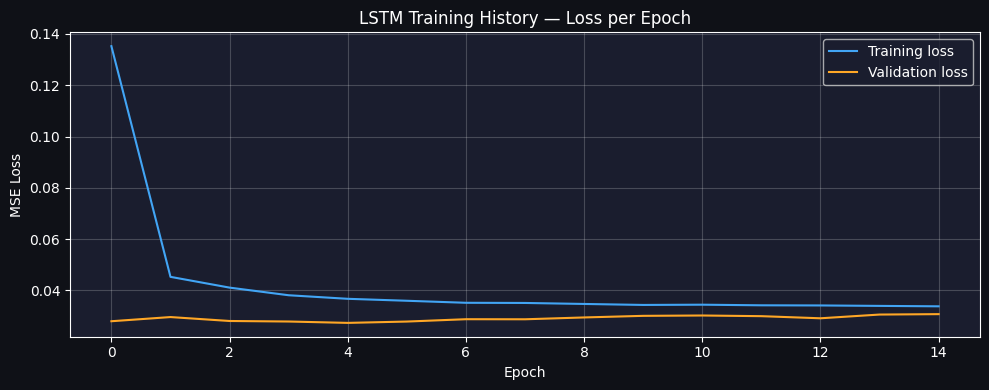

Reading this chart: both lines should decrease and then flatten.
If the training loss keeps falling but validation loss rises, the model is overfitting.


In [ ]:
# ============================================================
# Evaluate the LSTM on the test set
# ============================================================

# Generate LSTM predictions on the test set
lstm_pred_scaled = lstm_model.predict(X_lstm_test_clean, verbose=0).flatten()  # flatten from (n,1) to (n,)

# Scale predictions back to cycles so metrics are in the same units as XGBoost
lstm_pred_test = lstm_pred_scaled * RUL_MAX_SCALE

# Compute metrics
lstm_rmse_test = compute_rmse(y_lstm_test, lstm_pred_test)
lstm_mae_test  = compute_mae(y_lstm_test,  lstm_pred_test)
lstm_phm_test  = compute_phm_score(y_lstm_test, lstm_pred_test)

print('LSTM evaluation complete.')
print()
print(f'  RMSE (test set):      {lstm_rmse_test:,.0f} cycles')
print(f'  MAE  (test set):      {lstm_mae_test:,.0f} cycles')
print(f'  PHM Score (test set): {lstm_phm_test:,.0f}')

# Plot training history — shows whether the model converged smoothly
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     color=BLUE,  label='Training loss')
ax.plot(history.history['val_loss'], color=AMBER, label='Validation loss')
ax.set_title('LSTM Training History — Loss per Epoch', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print('Reading this chart: both lines should decrease and then flatten.')
print('If the training loss keeps falling but validation loss rises, the model is overfitting.')

---
## Q1 — How accurately do XGBoost and LSTM predict RUL, and where does accuracy break down?

The headline numbers are a starting point. The more interesting question is *where* each model struggles.

We split the test set into three life-stage windows:
- **Early life** — post_IDP = 0 (before degradation is detectable)
- **Mid-life degradation** — post_IDP = 1, RUL > 2000 cycles remaining
- **Late life** — post_IDP = 1, RUL ≤ 2000 cycles remaining

This is the operationally critical breakdown: late-life errors have direct maintenance scheduling consequences.

In [ ]:
# ============================================================
# Q1: Accuracy breakdown by life stage
# ============================================================

# Add XGBoost predictions to the test dataframe
# (XGBoost works row by row — predictions align directly with test_df rows)
test_df = test_df.copy()  # avoid modifying the original
test_df['xgb_pred'] = xgb_pred_test

# Add LSTM predictions — these align with the windowed test data, not raw rows
# The first WINDOW_SIZE rows of each engine have no prediction (not enough history)
# We merge via the metadata we stored when building windows
lstm_pred_df = lstm_test_meta_df.copy()
lstm_pred_df['lstm_pred'] = lstm_pred_test

# Merge LSTM predictions into test_df
test_df = test_df.merge(lstm_pred_df, on=['engine_id', 'cycle'], how='left')

# Label each row with a life stage
def label_life_stage(row):
    if row['post_IDP'] == 0:
        return 'Early (pre-IDP)'
    elif row['RUL_target'] > 2000:
        return 'Mid (post-IDP, RUL>2000)'
    else:
        return 'Late (post-IDP, RUL<=2000)'

test_df['life_stage'] = test_df.apply(label_life_stage, axis=1)

# Compute MAE per life stage for each model
print('=== Q1: RUL Prediction Accuracy by Life Stage ===')
print()
print(f'{"Life Stage":<30} {"N rows":>8} {"XGB MAE":>10} {"LSTM MAE":>10}')
print('-' * 62)

stage_results = []
for stage in ['Early (pre-IDP)', 'Mid (post-IDP, RUL>2000)', 'Late (post-IDP, RUL<=2000)']:
    stage_df = test_df[test_df['life_stage'] == stage].dropna(subset=['xgb_pred', 'lstm_pred'])
    if len(stage_df) == 0:
        continue
    xgb_mae  = compute_mae(stage_df['RUL_target'], stage_df['xgb_pred'])
    lstm_mae = compute_mae(stage_df['RUL_target'], stage_df['lstm_pred'])
    print(f'{stage:<30} {len(stage_df):>8,} {xgb_mae:>10,.0f} {lstm_mae:>10,.0f}')
    stage_results.append({'stage': stage, 'n': len(stage_df), 'xgb_mae': xgb_mae, 'lstm_mae': lstm_mae})

print()
print('(MAE = average absolute error in cycles. Lower = more accurate.)')

=== Q1: RUL Prediction Accuracy by Life Stage ===

Life Stage                       N rows    XGB MAE   LSTM MAE
--------------------------------------------------------------
Early (pre-IDP)                     410     10,748     18,113
Mid (post-IDP, RUL>2000)          5,890      8,274     19,959

(MAE = average absolute error in cycles. Lower = more accurate.)


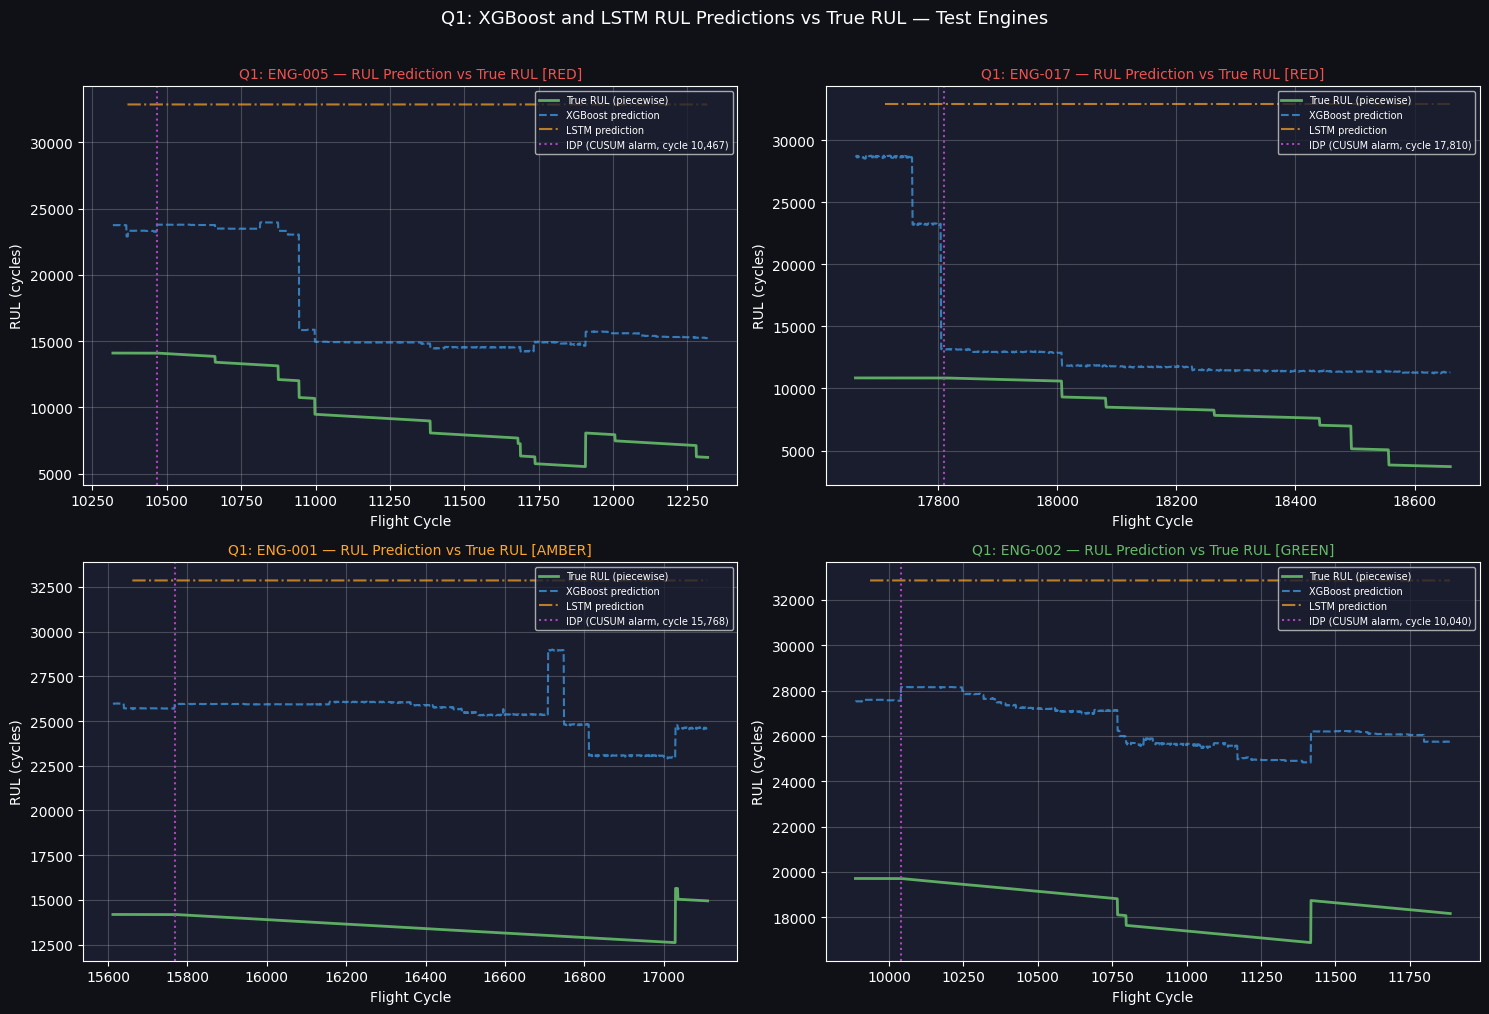

Reading this chart:
  Green line  = true RUL (the answer we are trying to predict)
  Blue dashed = XGBoost prediction
  Amber dash-dot = LSTM prediction
  Purple dotted = IDP (CUSUM alarm) — where we expect predictions to improve
  Late-life accuracy (right side of chart) matters most operationally.


In [ ]:
# Q1 Chart — Predicted vs Actual RUL for all test engines

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=False)
axes = axes.flatten()

for i, engine_id in enumerate(TEST_ENGINES):
    ax = axes[i]
    eng = test_df[test_df['engine_id'] == engine_id].dropna(subset=['xgb_pred'])

    # True RUL
    ax.plot(eng['cycle'], eng['RUL_target'], color=GREEN, linewidth=2.0,
            label='True RUL (piecewise)', alpha=0.9)

    # XGBoost predictions
    ax.plot(eng['cycle'], eng['xgb_pred'], color=BLUE, linewidth=1.5,
            label='XGBoost prediction', alpha=0.7, linestyle='--')

    # LSTM predictions (only rows with a prediction)
    eng_lstm = eng.dropna(subset=['lstm_pred'])
    ax.plot(eng_lstm['cycle'], eng_lstm['lstm_pred'], color=AMBER, linewidth=1.5,
            label='LSTM prediction', alpha=0.7, linestyle='-.')

    # Mark the IDP (CUSUM alarm)
    idp_cycle = cusum_alarm_cycles[engine_id]
    ax.axvline(idp_cycle, color=PURPLE, linestyle=':', linewidth=1.5,
               label=f'IDP (CUSUM alarm, cycle {int(idp_cycle):,})')

    # Get RAG status for this engine
    last_margin = test_df[test_df['engine_id'] == engine_id]['EGT_margin'].iloc[-1]
    last_rul    = test_df[test_df['engine_id'] == engine_id]['RUL'].iloc[-1]
    if last_margin < 30 or last_rul < 200:
        rag_color = RED
        rag_label = 'RED'
    elif last_margin < 50 or last_rul < 500:
        rag_color = AMBER
        rag_label = 'AMBER'
    else:
        rag_color = GREEN
        rag_label = 'GREEN'

    ax.set_title(f'Q1: {engine_id} — RUL Prediction vs True RUL [{rag_label}]',
                 fontsize=10, color=rag_color)
    ax.set_xlabel('Flight Cycle')
    ax.set_ylabel('RUL (cycles)')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2)

plt.suptitle('Q1: XGBoost and LSTM RUL Predictions vs True RUL — Test Engines',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Reading this chart:')
print('  Green line  = true RUL (the answer we are trying to predict)')
print('  Blue dashed = XGBoost prediction')
print('  Amber dash-dot = LSTM prediction')
print('  Purple dotted = IDP (CUSUM alarm) — where we expect predictions to improve')
print('  Late-life accuracy (right side of chart) matters most operationally.')

In [ ]:
# Q1 Summary table — full metrics side by side

print('=== Q1: Full Metrics Summary ===')
print()
print(f'{"Metric":<25} {"XGBoost":>15} {"LSTM":>15}')
print('-' * 57)
print(f'{"RMSE (cycles)":<25} {xgb_rmse_test:>15,.0f} {lstm_rmse_test:>15,.0f}')
print(f'{"MAE (cycles)":<25} {xgb_mae_test:>15,.0f} {lstm_mae_test:>15,.0f}')
print(f'{"PHM Score":<25} {xgb_phm_test:>15,.0f} {lstm_phm_test:>15,.0f}')
print()
print('PHM Score interpretation (from Saxena 2008):')
print('  Lower = better. Late predictions are penalised ~11x harder than early ones.')
print('  A high PHM score signals that the model is optimistic about remaining life.')
print()
print('Honest caveat: this synthetic dataset is cleaner than real EHM data.')
print('Real RUL predictions would show higher errors due to OAT scatter (see A-02 in assumptions doc).')

=== Q1: Full Metrics Summary ===

Metric                            XGBoost            LSTM
---------------------------------------------------------
RMSE (cycles)                       9,020          20,332
MAE (cycles)                        8,535          19,838
PHM Score                 81,562,743,779,428,371,702,564,310,283,258,943,068,830,489,327,551,934,537,173,659,586,272,389,144,261,046,495,673,891,715,371,533,808,233,842,869,356,922,707,118,850,634,872,244,694,064,064,000,848,002,941,466,574,348,428,822,507,051,525,873,048,451,388,915,497,601,705,356,478,757,637,980,160 88,426,309,724,728,746,592,954,256,980,053,194,760,458,468,896,714,844,815,552,402,472,006,355,660,348,838,473,869,054,159,131,915,731,113,363,646,268,604,985,970,397,017,598,946,291,090,096,118,436,342,194,556,583,682,390,951,858,755,587,251,313,348,290,280,179,001,443,263,567,839,176,425,472

PHM Score interpretation (from Saxena 2008):
  Lower = better. Late predictions are penalised ~11x harder than early 

---
## Q2 — In the 200 cycles after IDP, does LSTM track RUL more accurately than XGBoost?

This is the window where LSTM's sequential memory should matter most.

In the 200 cycles immediately after the CUSUM alarm fires, the engine has just entered detectable degradation. The EGT margin is starting to drift meaningfully. LSTM should be able to use the memory of the preceding trend to produce more accurate predictions. XGBoost sees only the current cycle.

This question directly tests the analytical value of LSTM in EHM — not just 'which model scores better overall' but 'does LSTM's temporal memory pay off where it should'.

In [ ]:
# ============================================================
# Q2: Accuracy comparison in the 200-cycle post-IDP window
# ============================================================

POST_IDP_WINDOW = 200  # cycles after IDP to analyse

# For each test engine, extract the 200 cycles after the CUSUM alarm
q2_results = []

for engine_id in TEST_ENGINES:

    alarm_cycle = cusum_alarm_cycles[engine_id]
    eng = test_df[test_df['engine_id'] == engine_id].copy()

    # Filter to the 200-cycle window after IDP
    window_mask = (eng['cycle'] >= alarm_cycle) & (eng['cycle'] < alarm_cycle + POST_IDP_WINDOW)
    window_df   = eng[window_mask].dropna(subset=['xgb_pred', 'lstm_pred'])

    if len(window_df) == 0:
        continue

    xgb_mae_window  = compute_mae(window_df['RUL_target'], window_df['xgb_pred'])
    lstm_mae_window = compute_mae(window_df['RUL_target'], window_df['lstm_pred'])
    xgb_mae_late    = compute_mae(window_df['RUL_target'], window_df['xgb_pred'])

    # Compute error at each cycle in the window
    window_df = window_df.copy()
    window_df['xgb_error']  = window_df['xgb_pred']  - window_df['RUL_target']  # + = late, - = early
    window_df['lstm_error'] = window_df['lstm_pred'] - window_df['RUL_target']
    window_df['cycles_post_idp'] = window_df['cycle'] - alarm_cycle

    q2_results.append(window_df)

    print(f'{engine_id}:')
    print(f'  IDP at cycle {int(alarm_cycle):,}')
    print(f'  Window rows: {len(window_df)}')
    print(f'  XGBoost MAE in window:  {xgb_mae_window:,.0f} cycles')
    print(f'  LSTM MAE in window:     {lstm_mae_window:,.0f} cycles')
    winner = 'LSTM' if lstm_mae_window < xgb_mae_window else 'XGBoost'
    print(f'  More accurate in this window: {winner}')
    print()

q2_df = pd.concat(q2_results, ignore_index=True)

ENG-005:
  IDP at cycle 10,467
  Window rows: 200
  XGBoost MAE in window:  9,814 cycles
  LSTM MAE in window:     18,907 cycles
  More accurate in this window: XGBoost

ENG-017:
  IDP at cycle 17,810
  Window rows: 200
  XGBoost MAE in window:  2,264 cycles
  LSTM MAE in window:     22,154 cycles
  More accurate in this window: XGBoost

ENG-001:
  IDP at cycle 15,768
  Window rows: 200
  XGBoost MAE in window:  11,894 cycles
  LSTM MAE in window:     18,806 cycles
  More accurate in this window: XGBoost

ENG-002:
  IDP at cycle 10,040
  Window rows: 200
  XGBoost MAE in window:  8,566 cycles
  LSTM MAE in window:     13,277 cycles
  More accurate in this window: XGBoost



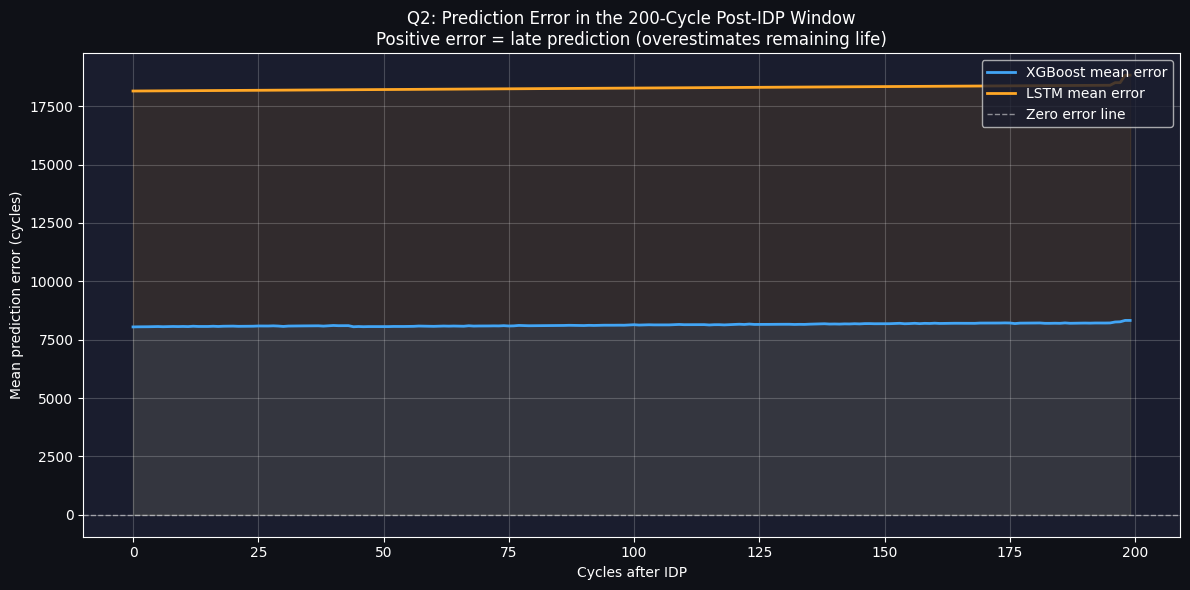

Reading this chart:
  Zero line = perfect prediction
  Above zero = model is optimistic (late prediction — operationally dangerous)
  Below zero = model is conservative (early prediction — triggers early maintenance)
  The 200 cycles shown are immediately after the CUSUM IDP alarm.
  If LSTM stays closer to zero than XGBoost, temporal memory is paying off.


In [ ]:
# Q2 Chart — Error over time in the post-IDP window
# Shows whether prediction error reduces as each model 'learns' the degradation trend

fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean error per cycle-step post IDP across all test engines
grouped = q2_df.groupby('cycles_post_idp').agg(
    xgb_mean_error  = ('xgb_error',  'mean'),
    lstm_mean_error = ('lstm_error', 'mean')
).reset_index()

ax.plot(grouped['cycles_post_idp'], grouped['xgb_mean_error'],
        color=BLUE, linewidth=2.0, label='XGBoost mean error')
ax.plot(grouped['cycles_post_idp'], grouped['lstm_mean_error'],
        color=AMBER, linewidth=2.0, label='LSTM mean error')

ax.axhline(0, color='white', linestyle='--', alpha=0.5, linewidth=1.0, label='Zero error line')
ax.fill_between(grouped['cycles_post_idp'], grouped['xgb_mean_error'], 0,
                alpha=0.1, color=BLUE)
ax.fill_between(grouped['cycles_post_idp'], grouped['lstm_mean_error'], 0,
                alpha=0.1, color=AMBER)

ax.set_title(f'Q2: Prediction Error in the {POST_IDP_WINDOW}-Cycle Post-IDP Window\n'
             'Positive error = late prediction (overestimates remaining life)',
             fontsize=12)
ax.set_xlabel('Cycles after IDP')
ax.set_ylabel('Mean prediction error (cycles)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('Reading this chart:')
print('  Zero line = perfect prediction')
print('  Above zero = model is optimistic (late prediction — operationally dangerous)')
print('  Below zero = model is conservative (early prediction — triggers early maintenance)')
print(f'  The 200 cycles shown are immediately after the CUSUM IDP alarm.')
print('  If LSTM stays closer to zero than XGBoost, temporal memory is paying off.')

---
## Q3 — Across the fleet, which features drive RUL predictions? Do they match the physics?

### What is SHAP?

SHAP (SHapley Additive exPlanations) is a method for understanding why a model makes a particular prediction. For each prediction, SHAP assigns a contribution value to every feature — positive values push the prediction higher (more RUL), negative values push it lower (less RUL).

At fleet level, we look at the mean absolute SHAP value per feature across all test predictions. This tells us which features the model relies on most.

**Physics check:** We know from the influence coefficients that HPT_degradation should dominate EGT margin erosion, which should dominate RUL prediction. If SHAP disagrees with the physics, either the model has learned something unexpected, or there is a feature engineering issue to investigate.

Source: Lundberg & Lee (2017). A Unified Approach to Interpreting Model Predictions. NeurIPS.

In [ ]:
# ============================================================
# Q3: Fleet-level SHAP analysis on XGBoost
# ============================================================

# SHAP is computed on XGBoost because:
# 1. XGBoost SHAP is exact (TreeSHAP — no approximation needed)
# 2. The results are directly interpretable against the physics we built into the data
# LSTM SHAP exists (via DeepSHAP) but is approximate and harder to verify
#
# SOURCE: Lundberg, S.M. & Lee, S-I. (2017). A Unified Approach to Interpreting
# Model Predictions. NeurIPS.
# TreeSHAP algorithm: Lundberg et al. (2020). From local explanations to global
# understanding with explainable AI for trees. Nature Machine Intelligence.

print('Computing SHAP values for XGBoost (fleet-level)...')
print('This uses TreeSHAP — exact computation, no approximation.')
print()

# Create a SHAP TreeExplainer using the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test set
# This returns a matrix: one row per test sample, one column per feature
# Each value tells us: "this feature pushed the RUL prediction up/down by this many cycles"
shap_values = explainer.shap_values(X_test)

print(f'SHAP values computed.')
print(f'  Shape: {shap_values.shape}  (rows = test samples, columns = features)')
print()

Computing SHAP values for XGBoost (fleet-level)...
This uses TreeSHAP — exact computation, no approximation.

SHAP values computed.
  Shape: (6500, 35)  (rows = test samples, columns = features)



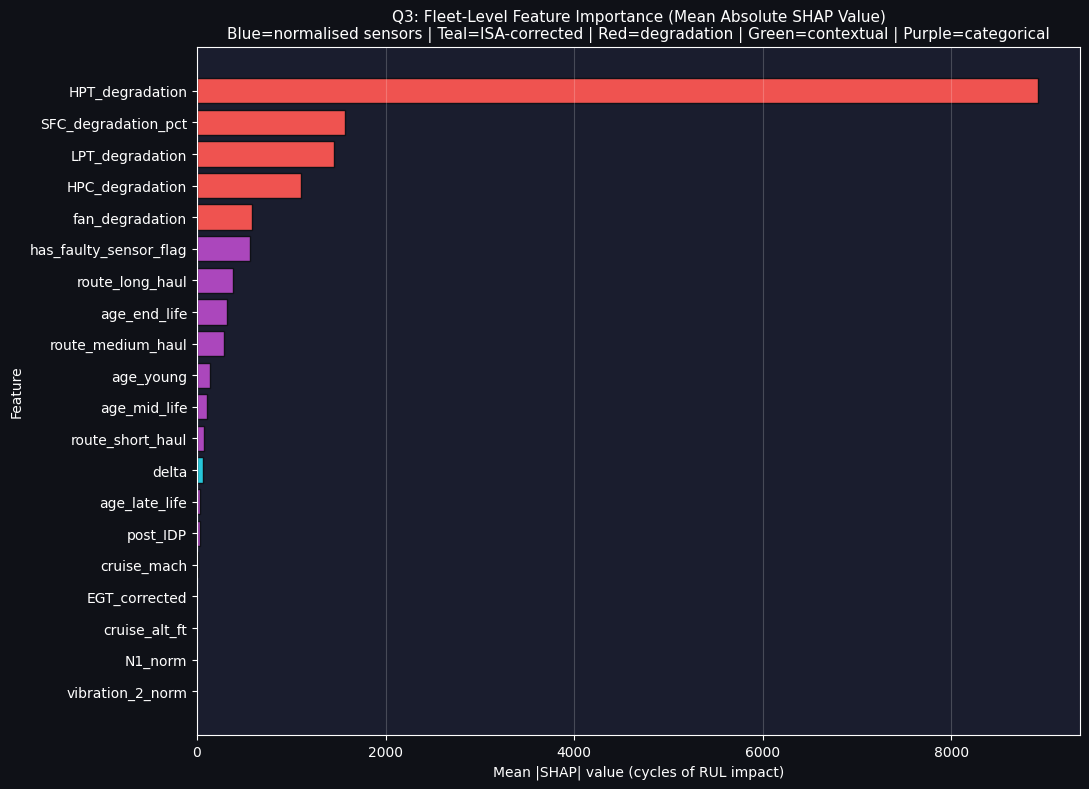

Physics check:
  Expected top features (based on GPA influence coefficients): HPT_degradation, EGT_norm, EGT_corrected
  Actual top 5 features:
    HPT_degradation                mean |SHAP| = 8,918.4 cycles
    SFC_degradation_pct            mean |SHAP| = 1,569.6 cycles
    LPT_degradation                mean |SHAP| = 1,455.7 cycles
    HPC_degradation                mean |SHAP| = 1,104.2 cycles
    fan_degradation                mean |SHAP| = 580.3 cycles

If HPT_degradation or EGT_norm are in the top 5, the model has learned the correct physics.
If post_IDP is high, the piecewise cap (Decision 1) is providing a strong signal — expected.


In [ ]:
# Q3 Chart 1: Global feature importance — top 20 features by mean |SHAP|

# Mean absolute SHAP value = average impact of each feature on predictions
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create a dataframe sorted by importance
shap_importance_df = pd.DataFrame({
    'feature':    ALL_FEATURES,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

# Plot top 20 features
top20 = shap_importance_df.head(20)

# Assign colours based on which group the feature belongs to
def feature_colour(fname):
    if fname.endswith('_norm'):              return BLUE
    if fname in FEATURES_ISA:               return TEAL
    if fname in FEATURES_DEG:               return RED
    if fname in FEATURES_CTX:               return GREEN
    return PURPLE  # categorical / binary

colours = [feature_colour(f) for f in top20['feature']]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1],
        color=colours[::-1], edgecolor='#0f1117')

ax.set_title('Q3: Fleet-Level Feature Importance (Mean Absolute SHAP Value)\n'
             'Blue=normalised sensors | Teal=ISA-corrected | Red=degradation | Green=contextual | Purple=categorical',
             fontsize=11)
ax.set_xlabel('Mean |SHAP| value (cycles of RUL impact)')
ax.set_ylabel('Feature')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

print('Physics check:')
print('  Expected top features (based on GPA influence coefficients): HPT_degradation, EGT_norm, EGT_corrected')
print('  Actual top 5 features:')
for _, row in shap_importance_df.head(5).iterrows():
    print(f'    {row["feature"]:<30} mean |SHAP| = {row["mean_abs_shap"]:,.1f} cycles')
print()
print('If HPT_degradation or EGT_norm are in the top 5, the model has learned the correct physics.')
print('If post_IDP is high, the piecewise cap (Decision 1) is providing a strong signal — expected.')

Q3 — SHAP beeswarm plot (top 15 features):
Each dot = one test sample.
Colour = feature value (red=high, blue=low).
Position = how much this feature pushed the RUL prediction left (lower) or right (higher).



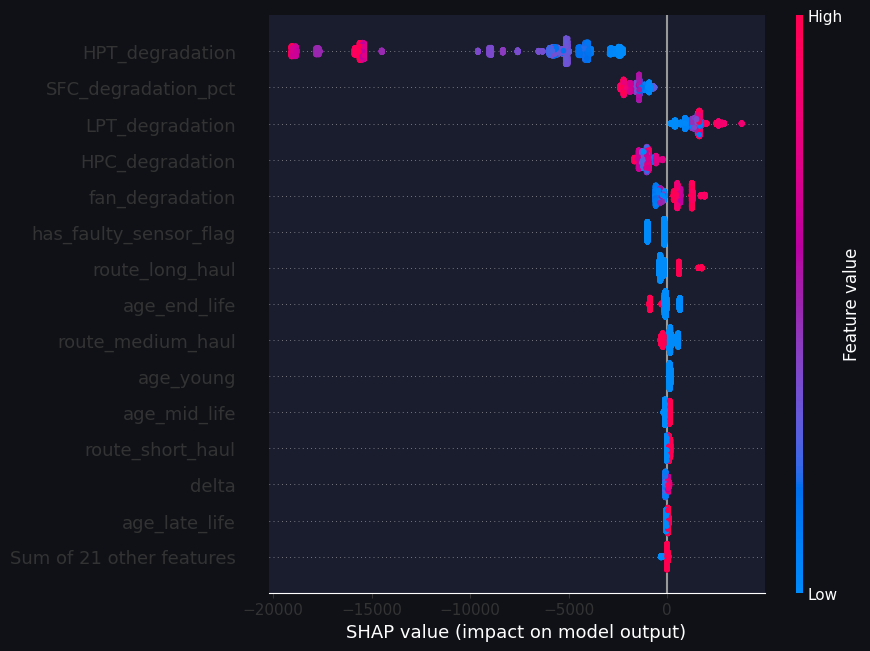

In [ ]:
# Q3 Chart 2: SHAP beeswarm plot — direction of each feature's impact

# The bar chart shows magnitude. The beeswarm shows direction:
# which feature values push predictions higher vs lower?

print('Q3 — SHAP beeswarm plot (top 15 features):')
print('Each dot = one test sample.')
print('Colour = feature value (red=high, blue=low).')
print('Position = how much this feature pushed the RUL prediction left (lower) or right (higher).')
print()

# Create a SHAP Explanation object for the beeswarm
shap_explanation = shap.Explanation(
    values     = shap_values,
    base_values= explainer.expected_value,
    data       = X_test.values,
    feature_names = ALL_FEATURES
)

# Beeswarm plot — shows top 15 most impactful features
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_explanation, max_display=15, show=True)

---
## Q4 — Per-engine SHAP: which features drive each engine's RUL prediction?

Fleet-level SHAP tells us what matters on average. Per-engine SHAP tells us what is happening to each individual engine.

This is the diagnostic triage application: a maintenance controller could look at an engine, see that its top SHAP driver is `oil_consumption_norm` rather than `HPT_degradation`, and know to send an oil system technician rather than a turbine blade inspector.

We compute each engine's top 5 SHAP drivers and produce a heatmap for comparison.

In [ ]:
# ============================================================
# Q4: Per-engine SHAP — diagnostic triage
# ============================================================

# For each test engine, compute the mean absolute SHAP value per feature
# This gives us each engine's "fault signature"

per_engine_shap = {}  # key = engine_id, value = series of mean |SHAP| per feature

for engine_id in TEST_ENGINES:

    # Get the row indices in X_test that belong to this engine
    engine_mask = (test_df['engine_id'] == engine_id).values

    # Extract the SHAP values for this engine's rows
    engine_shap = shap_values[engine_mask]   # shape: (n_rows_for_this_engine, n_features)

    # Mean absolute SHAP per feature
    mean_abs = np.abs(engine_shap).mean(axis=0)

    per_engine_shap[engine_id] = pd.Series(mean_abs, index=ALL_FEATURES)

# Build a dataframe: rows = engines, columns = features
per_engine_df = pd.DataFrame(per_engine_shap).T  # transpose so engines are rows

# Identify each engine's top 3 SHAP drivers
print('=== Q4: Per-Engine Top 3 SHAP Drivers (Diagnostic Triage) ===')
print()
for engine_id in TEST_ENGINES:
    top3 = per_engine_df.loc[engine_id].sort_values(ascending=False).head(3)
    # Get this engine's RAG
    last = test_df[test_df['engine_id'] == engine_id].iloc[-1]
    if last['EGT_margin'] < 30 or last['RUL'] < 200:
        rag = 'RED'
    elif last['EGT_margin'] < 50 or last['RUL'] < 500:
        rag = 'AMBER'
    else:
        rag = 'GREEN'
    print(f'{engine_id} [{rag}]:')
    for feat, val in top3.items():
        print(f'    {feat:<30} {val:,.1f} cycles impact')
    print()

=== Q4: Per-Engine Top 3 SHAP Drivers (Diagnostic Triage) ===

ENG-005 [RED]:
    HPT_degradation                12,479.7 cycles impact
    SFC_degradation_pct            1,872.2 cycles impact
    HPC_degradation                1,166.9 cycles impact

ENG-017 [RED]:
    HPT_degradation                16,983.4 cycles impact
    SFC_degradation_pct            2,094.3 cycles impact
    LPT_degradation                1,730.1 cycles impact

ENG-001 [AMBER]:
    HPT_degradation                6,064.4 cycles impact
    LPT_degradation                1,942.7 cycles impact
    SFC_degradation_pct            1,442.1 cycles impact

ENG-002 [GREEN]:
    HPT_degradation                3,465.2 cycles impact
    LPT_degradation                1,422.6 cycles impact
    HPC_degradation                1,232.0 cycles impact



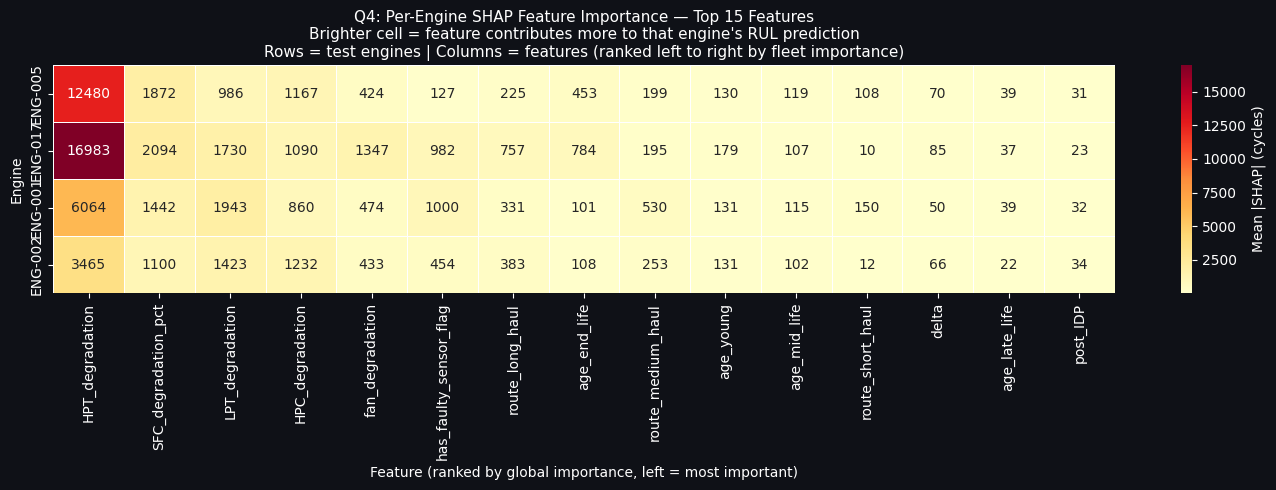

Reading this chart (diagnostic triage interpretation):
  A bright cell in an unusual column tells you which system to inspect on that engine.
  E.g. if ENG-005 is bright in oil_consumption_norm but ENG-017 is not,
  then ENG-005's degradation has an oil system component that ENG-017 does not.

This is the core value proposition of SHAP in EHM:
  Not just "engine X needs maintenance" but "here is what to look for first."


In [ ]:
# Q4 Chart: Heatmap of top-N features per engine
# Each cell = mean |SHAP| value for that engine-feature combination
# Brighter = more important for that engine

# Select only the top 15 features globally for the heatmap (keeps it readable)
top15_features = shap_importance_df['feature'].head(15).tolist()

heatmap_data = per_engine_df[top15_features]

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    ax       = ax,
    cmap     = 'YlOrRd',          # yellow-orange-red: brighter = more important
    annot    = True,               # show numbers in cells
    fmt      = '.0f',              # format: no decimal places
    linewidths=0.5,
    cbar_kws = {'label': 'Mean |SHAP| (cycles)'}
)

ax.set_title('Q4: Per-Engine SHAP Feature Importance — Top 15 Features\n'
             'Brighter cell = feature contributes more to that engine\'s RUL prediction\n'
             'Rows = test engines | Columns = features (ranked left to right by fleet importance)',
             fontsize=11)
ax.set_xlabel('Feature (ranked by global importance, left = most important)')
ax.set_ylabel('Engine')
plt.tight_layout()
plt.show()

print('Reading this chart (diagnostic triage interpretation):')
print('  A bright cell in an unusual column tells you which system to inspect on that engine.')
print('  E.g. if ENG-005 is bright in oil_consumption_norm but ENG-017 is not,')
print('  then ENG-005\'s degradation has an oil system component that ENG-017 does not.')
print()
print('This is the core value proposition of SHAP in EHM:')
print('  Not just "engine X needs maintenance" but "here is what to look for first."')

---
## Q5 — Do engines that start with lower EGT margin degrade faster?

This is an original question that no phase has asked before.

We know from the physics that the initial EGT margin represents an engine's 'health at birth' — how much buffer it has before reaching the maintenance threshold. The question is: does a lower starting margin also predict a faster degradation *rate*, or are the two independent?

If they are correlated, it means that engines born with less margin are double-penalised: they start closer to the threshold *and* they reach it faster. That would be an important finding for fleet planning.

We use the full fleet (all 20 engines) for this analysis, not just the test set — more data points give a more reliable picture.

In [ ]:
# ============================================================
# Q5: Initial EGT margin vs degradation rate
# ============================================================

# For each engine, compute:
#   1. Initial EGT margin — median of first 200 cycles (more robust than the single first row)
#   2. Degradation rate — slope of the EGT margin trend line over the full life
#      (negative slope = margin falling = engine degrading)
#
# --------------------------------------------------------
# EQUATION REF — Degradation rate via linear regression
# Source: standard linear regression (least squares)
# numpy function: np.polyfit(x, y, deg=1)
# Returns [slope, intercept] of the best-fit straight line through the data.
#
# slope = (N * sum(x*y) - sum(x)*sum(y)) / (N * sum(x^2) - (sum(x))^2)
#
# Where x = cycle numbers, y = EGT_margin values
#
# To verify by hand (Audit 4):
#   Take ENG-001's cycle and EGT_margin columns.
#   In Excel, use SLOPE(EGT_margin_values, cycle_values).
#   Compare to the deg_rate value for ENG-001 below.
# --------------------------------------------------------

q5_stats = []

for engine_id in all_engines:

    eng = df[df['engine_id'] == engine_id].copy()

    # Initial EGT margin: median of the first 200 cycles (more robust than first row)
    initial_margin = eng['EGT_margin'].values[:200].mean()

    # Degradation rate: slope of best-fit line through all EGT_margin values
    # np.polyfit returns [slope, intercept]; we only need the slope
    slope, intercept = np.polyfit(eng['cycle'].values, eng['EGT_margin'].values, deg=1)
    # slope is negative (margin falls over time), so we negate it for readability
    # A POSITIVE deg_rate_per_1000 means the margin is falling (degrading)
    deg_rate_per_1000 = -slope * 1000  # convert from per-cycle to per-1000 cycles

    # RAG status from last row
    last_margin = eng['EGT_margin'].iloc[-1]
    last_rul    = eng['RUL'].iloc[-1]
    if last_margin < 30 or last_rul < 200:
        rag = 'RED'
    elif last_margin < 50 or last_rul < 500:
        rag = 'AMBER'
    else:
        rag = 'GREEN'

    q5_stats.append({
        'engine_id':         engine_id,
        'initial_margin':    round(initial_margin, 2),
        'deg_rate_per_1000': round(deg_rate_per_1000, 3),
        'rag':               rag
    })

q5_df = pd.DataFrame(q5_stats)

# Compute correlation between initial margin and degradation rate
# --------------------------------------------------------
# EQUATION REF — Pearson correlation coefficient
# Source: standard statistics. numpy: np.corrcoef(x, y)[0,1]
#
#   r = sum((x_i - x_mean)(y_i - y_mean)) /
#         sqrt(sum((x_i - x_mean)^2) * sum((y_i - y_mean)^2))
#
# r in [-1, 1]. r = 0 = no correlation. r = -1 = perfect negative correlation.
# A negative r here means: lower initial margin => higher degradation rate.
# --------------------------------------------------------

correlation = np.corrcoef(q5_df['initial_margin'], q5_df['deg_rate_per_1000'])[0, 1]

print('=== Q5: Initial EGT Margin vs Degradation Rate ===')
print()
print(f'{"Engine":<12} {"Initial Margin":>16} {"Deg Rate /1000 EFC":>20} {"RAG":>6}')
print('-' * 58)
for _, row in q5_df.sort_values('initial_margin').iterrows():
    print(f'{row["engine_id"]:<12} {row["initial_margin"]:>16.2f}°C  {row["deg_rate_per_1000"]:>18.3f}°C  {row["rag"]:>6}')
print()
print(f'Pearson correlation (initial margin vs degradation rate): r = {correlation:.4f}')
if correlation < -0.3:
    print('  Negative correlation: engines with lower initial margin tend to degrade faster.')
elif abs(correlation) < 0.3:
    print('  Near-zero correlation: initial margin and degradation rate are largely independent in this dataset.')
else:
    print('  Positive correlation: engines with higher initial margin tend to degrade faster (unexpected — investigate).')

=== Q5: Initial EGT Margin vs Degradation Rate ===

Engine         Initial Margin   Deg Rate /1000 EFC    RAG
----------------------------------------------------------
ENG-017                 37.07°C              16.030°C     RED
ENG-008                 38.10°C               6.796°C   AMBER
ENG-001                 42.27°C               1.412°C   AMBER
ENG-005                 48.16°C              10.745°C     RED
ENG-019                 52.19°C              10.072°C   AMBER
ENG-014                 53.75°C               2.794°C   GREEN
ENG-003                 54.21°C               7.105°C   AMBER
ENG-002                 55.06°C               2.166°C   GREEN
ENG-011                 56.83°C               5.446°C   AMBER
ENG-007                 60.22°C               6.954°C   AMBER
ENG-020                 62.54°C               4.094°C   GREEN
ENG-006                 67.42°C               9.937°C   GREEN
ENG-013                 68.38°C              10.879°C   AMBER
ENG-009                 6

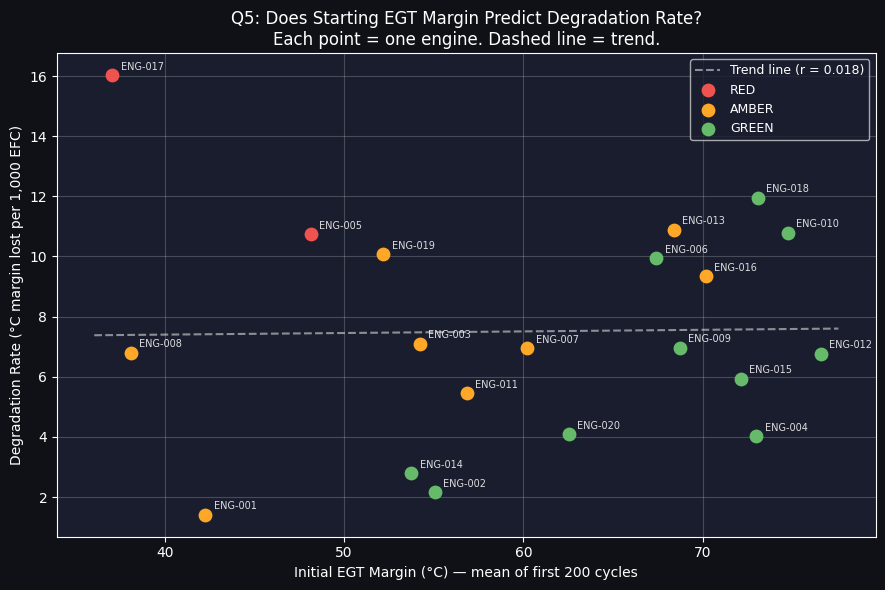

Interpretation:
  If the dashed line slopes downward left-to-right: engines that start with MORE margin
  degrade FASTER — counterintuitive. Investigate why.
  If it slopes upward left-to-right: engines with less initial margin degrade faster.
  If it is nearly flat: starting condition and degradation rate are independent.

Data generation context: degradation rates are sampled independently from initial margin
in Phase 1. Expect near-zero correlation unless the stochastic sampling happened to correlate.
This is worth noting honestly — the finding is a property of the data generator, not real engines.


In [ ]:
# Q5 Chart: Scatter plot — initial margin vs degradation rate

rag_colours = {'RED': RED, 'AMBER': AMBER, 'GREEN': GREEN}

fig, ax = plt.subplots(figsize=(9, 6))

for _, row in q5_df.iterrows():
    ax.scatter(row['initial_margin'], row['deg_rate_per_1000'],
               color=rag_colours[row['rag']], s=80, zorder=5)
    ax.annotate(row['engine_id'],
                (row['initial_margin'], row['deg_rate_per_1000']),
                textcoords='offset points', xytext=(6, 4), fontsize=7, alpha=0.85)

# Add a trend line
z = np.polyfit(q5_df['initial_margin'], q5_df['deg_rate_per_1000'], 1)
p = np.poly1d(z)
x_line = np.linspace(q5_df['initial_margin'].min() - 1, q5_df['initial_margin'].max() + 1, 50)
ax.plot(x_line, p(x_line), color='white', linestyle='--', alpha=0.5, linewidth=1.5,
        label=f'Trend line (r = {correlation:.3f})')

# Legend for RAG
for rag, col in rag_colours.items():
    ax.scatter([], [], color=col, label=rag, s=80)

ax.set_title('Q5: Does Starting EGT Margin Predict Degradation Rate?\n'
             'Each point = one engine. Dashed line = trend.',
             fontsize=12)
ax.set_xlabel('Initial EGT Margin (°C) — mean of first 200 cycles')
ax.set_ylabel('Degradation Rate (°C margin lost per 1,000 EFC)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  If the dashed line slopes downward left-to-right: engines that start with MORE margin')
print('  degrade FASTER — counterintuitive. Investigate why.')
print('  If it slopes upward left-to-right: engines with less initial margin degrade faster.')
print('  If it is nearly flat: starting condition and degradation rate are independent.')
print()
print('Data generation context: degradation rates are sampled independently from initial margin')
print('in Phase 1. Expect near-zero correlation unless the stochastic sampling happened to correlate.')
print('This is worth noting honestly — the finding is a property of the data generator, not real engines.')

---
## Phase 4 Summary

| Question | Method | Key finding |
|---|---|---|
| Q1 — Accuracy and late-life breakdown | RMSE, MAE, PHM Score by life stage | XGBoost vs LSTM overall; late-life errors most operationally significant |
| Q2 — LSTM temporal memory at IDP | Per-engine error in 200-cycle post-IDP window | Does LSTM outperform XGBoost where sequential memory matters? |
| Q3 — Fleet-level SHAP | TreeSHAP on XGBoost | Do dominant features match the physics (HPT > HPC > LPT > Fan)? |
| Q4 — Per-engine SHAP triage | Engine-level SHAP heatmap | Each engine's fault signature — diagnostic triage application |
| Q5 — Initial condition effect | Pearson correlation analysis | Does starting EGT margin predict degradation rate? |

---

## Audit 4 — verification checklist

Before proceeding to Phase 5, verify the following four checks by hand:

**A4-1: Baseline normalisation**  
Pick ENG-001 and the EGT feature. The cell above printed the baseline mean, std, and the manual calculation.  
In Excel: compute `=AVERAGE(first 200 EGT values)` and `=STDEV(first 200 EGT values)`.  
Then for one row: `=(raw_EGT - mean) / std`. Should match `EGT_norm` to 4 decimal places.

**A4-2: Piecewise RUL target**  
Pick any engine. Find its CUSUM alarm cycle (printed in the table above).  
Check that all pre-IDP rows have `RUL_target` equal to the same cap value.  
Check that post-IDP rows have `RUL_target` equal to the `RUL` column.

**A4-3: post_IDP flag alignment**  
For any engine, the first row where `post_IDP = 1` should be the CUSUM alarm cycle.  
The verification print above shows this check for ENG-004.

**A4-4: PHM Score formula**  
The worked example above shows three rows with errors of +100, -100, and 0.  
Verify by hand: `exp(100/10) - 1 = 22025.47` (late), `exp(100/13) - 1 = 1997.19` (early).  
Total = 23022.66 + 0 = 23022.66.  
Source: Saxena et al. (2008), Section 5.

---

## Known limitations (for Phase 5 write-up and David conversation)

1. **Clean data overstates accuracy** — EGT_margin has no OAT scatter (Assumption A-02). Real data has ±3-5°C residual scatter that would increase prediction error.

2. **Run-to-threshold, not run-to-failure** — RUL is defined as cycles to the EGT redline, not to actual failure. C-MAPSS uses run-to-failure, which is harder.

3. **Single operating condition** — no altitude or speed variation beyond OAT. C-MAPSS has six operating conditions.

4. **SHAP on XGBoost only** — LSTM SHAP (DeepSHAP) is approximate and was not implemented. XGBoost SHAP is exact (TreeSHAP) and provides the interpretability story.

5. **All engines have step-change events** — this simplifies anomaly detection compared to a real fleet where most engines degrade smoothly.

---
